In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

source = "/content/drive/MyDrive/Facial emotion dataset"
destination = "/content/Facial emotion dataset"

if os.path.exists(destination):
    shutil.rmtree(destination)

print("Copying dataset to Colab...")
shutil.copytree(source, destination)

print("Dataset copied successfully!")

Copying dataset to Colab...
Dataset copied successfully!


In [ ]:
import os

print("Dataset folders:")
print(os.listdir("/content/Facial emotion dataset"))

Dataset folders:
['test', 'train']


In [ ]:
train_dir = "/content/Facial emotion dataset/train"
test_dir = "/content/Facial emotion dataset/test"

print("Train classes:")
print(os.listdir(train_dir))

print("\nTest classes:")
print(os.listdir(test_dir))

Train classes:
['happy', 'surprise', 'neutral', 'sad', 'disgust', 'angry', 'fear']

Test classes:
['happy', 'surprise', 'neutral', 'sad', 'disgust', 'angry', 'fear']


In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 28750 files belonging to 7 classes.
Found 2261 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (64, 48, 48, 1)
Label batch shape: (64, 7)


In [ ]:

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

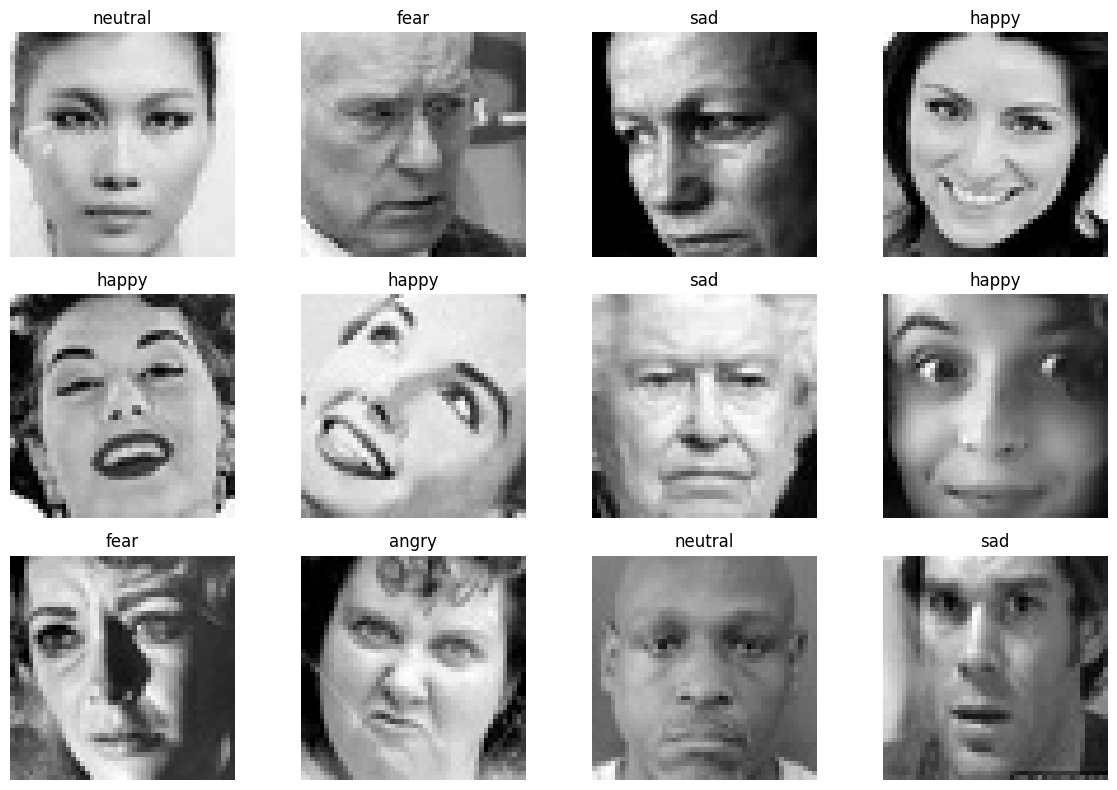

In [ ]:
import matplotlib.pyplot as plt

class_names = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        label = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(48, 48, 1)),

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(7, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

Found 28750 files belonging to 7 classes.
Using 23000 files for training.
Found 28750 files belonging to 7 classes.
Using 5750 files for validation.
Found 2261 files belonging to 7 classes.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.2690 - loss: 1.7894 - val_accuracy: 0.4645 - val_loss: 1.5866
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3914 - loss: 1.5764 - val_accuracy: 0.4791 - val_loss: 1.4794
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4379 - loss: 1.4629 - val_accuracy: 0.4777 - val_loss: 1.4402
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4709 - loss: 1.3878 - val_accuracy: 0.5523 - val_loss: 1.2304
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4918 - loss: 1.3395 - val_accuracy: 0.5388 - val_loss: 1.3038
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5076 - loss: 1.2957 - val_accuracy: 0.5557 - val_loss: 1.2633
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5216 - loss: 1.2528 - val_accuracy: 0.5612 - val_loss: 1.2451
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5362 - loss: 1.2257 - val_accu

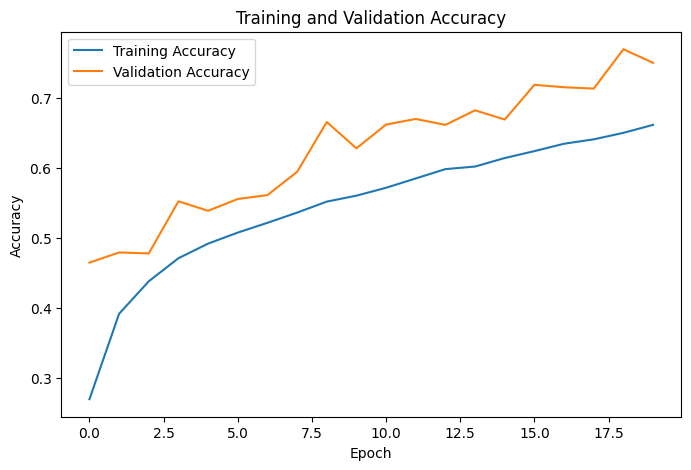

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

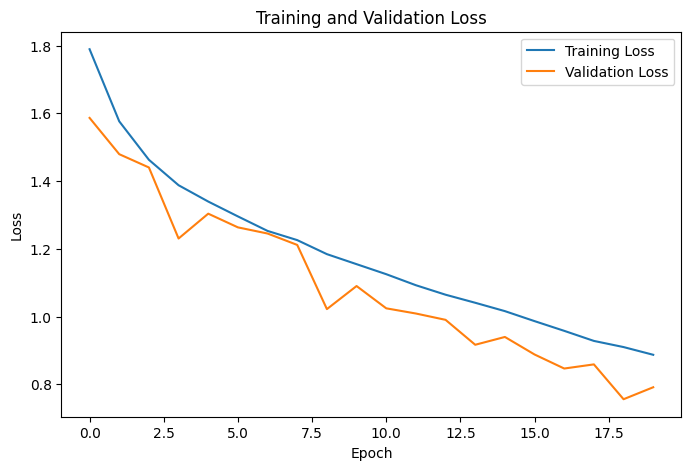

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5002 - loss: 1.4360
Test Loss: 1.4359660148620605
Test Accuracy: 0.5002211332321167


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.76      0.49      0.60       958
     disgust       1.00      0.17      0.29       111
        fear       0.00      0.00      0.00         0
       happy       0.00      0.00      0.00         0
     neutral       0.84      0.54      0.66      1192
         sad       0.00      0.00      0.00         0
    surprise       0.00      0.00      0.00         0

    accuracy                           0.50      2261
   macro avg       0.37      0.17      0.22      2261
weighted avg       0.81      0.50      0.61      2261



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


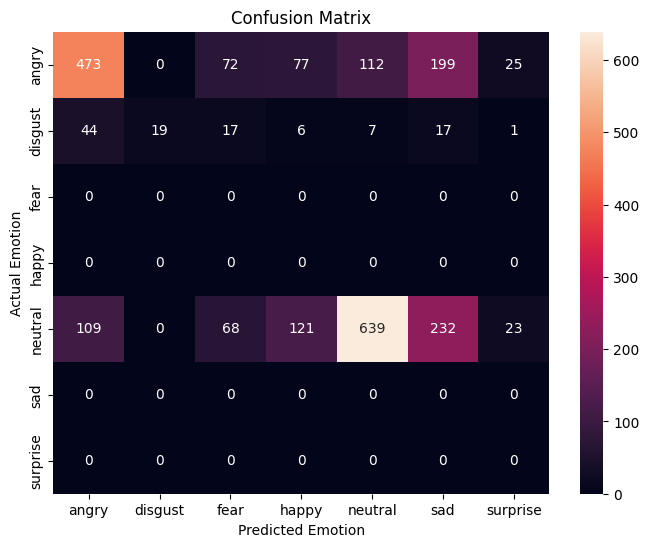

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix")
plt.show()

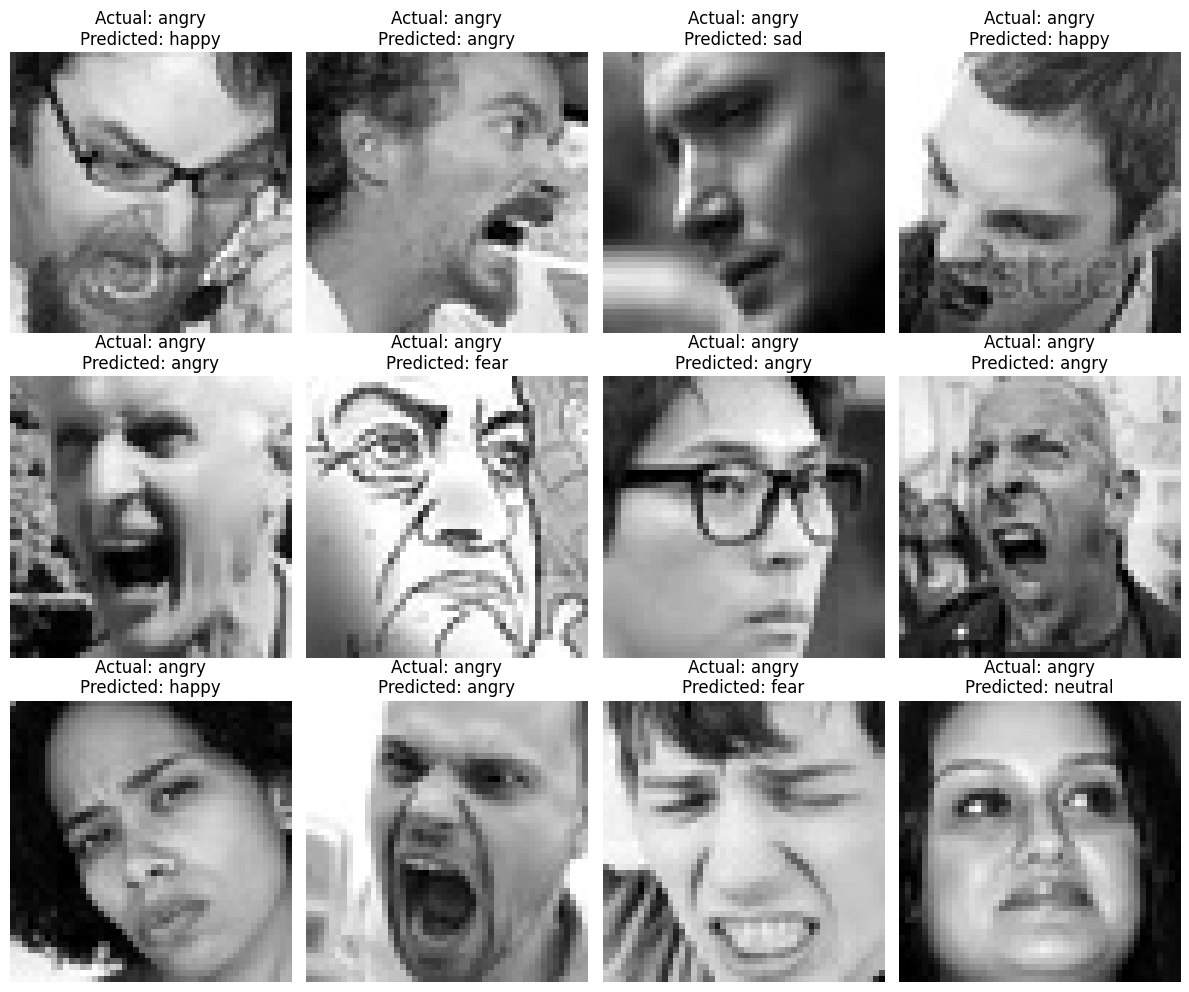

In [ ]:
plt.figure(figsize=(12, 10))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(12):

        actual = class_names[np.argmax(labels[i].numpy())]
        predicted = class_names[np.argmax(predictions[i])]

        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/facial_emotion_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
print("====================================")
print("FACIAL EMOTION DETECTION RESULTS")
print("====================================")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)
print("Number of Classes:", len(class_names))
print("Classes:", class_names)

FACIAL EMOTION DETECTION RESULTS
Test Accuracy: 0.5002211332321167
Test Loss: 1.4359660148620605
Number of Classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
print("====================================")
print("FACIAL EMOTION DETECTION RESULTS")
print("====================================")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)
print("Number of Classes:", len(class_names))
print("Classes:", class_names)

FACIAL EMOTION DETECTION RESULTS
Test Accuracy: 0.5002211332321167
Test Loss: 1.4359660148620605
Number of Classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
import pandas as pd
import numpy as np

# Get predictions for the test dataset
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    actual_labels = np.argmax(labels.numpy(), axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(actual_labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Create comparison table
comparison_df = pd.DataFrame({
    "Actual Emotion": [class_names[i] for i in y_true],
    "Predicted Emotion": [class_names[i] for i in y_pred]
})

# Add Correct/Incorrect column
comparison_df["Result"] = np.where(
    comparison_df["Actual Emotion"] == comparison_df["Predicted Emotion"],
    "Correct",
    "Incorrect"
)

print("Actual vs Predicted Comparison:")
display(comparison_df.head(30))

Actual vs Predicted Comparison:


,Actual Emotion,Predicted Emotion,Result
0,angry,happy,Incorrect
1,angry,angry,Correct
2,angry,sad,Incorrect
3,angry,happy,Incorrect
4,angry,angry,Correct
5,angry,fear,Incorrect
6,angry,angry,Correct
7,angry,angry,Correct
8,angry,happy,Incorrect
9,angry,angry,Correct


In [ ]:
correct = np.sum(y_true == y_pred)
total = len(y_true)

comparison_accuracy = (correct / total) * 100

print("Total Test Images:", total)
print("Correct Predictions:", correct)
print("Incorrect Predictions:", total - correct)
print("Actual vs Predicted Accuracy: {:.2f}%".format(comparison_accuracy))

Total Test Images: 2261
Correct Predictions: 1131
Incorrect Predictions: 1130
Actual vs Predicted Accuracy: 50.02%


In [ ]:
model.evaluate(test_dataset)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5002 - loss: 1.4360


[1.4359660148620605, 0.5002211332321167]

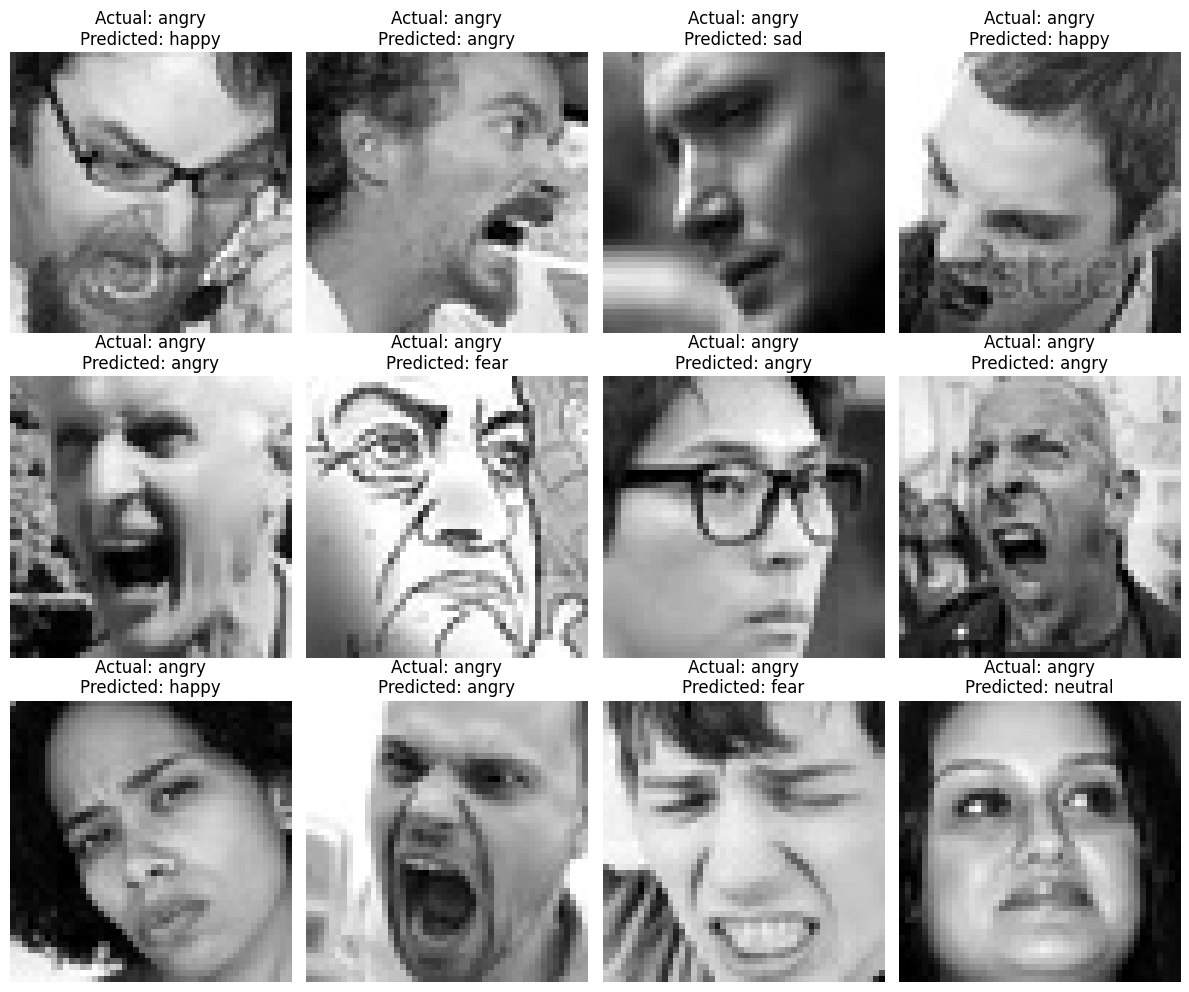

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(12):

        actual = class_names[np.argmax(labels[i].numpy())]
        predicted = class_names[np.argmax(predictions[i])]

        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving surprise.jpg to surprise.jpg


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Load image
img = load_img(
    filename,
    target_size=(48, 48),
    color_mode="grayscale"
)

# Convert image to array
img_array = img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_emotion = class_names[predicted_index]

# Confidence
confidence = prediction[0][predicted_index] * 100

print("Predicted Emotion:", predicted_emotion)
print("Confidence: {:.2f}%".format(confidence))

Predicted Emotion: fear
Confidence: 64.26%


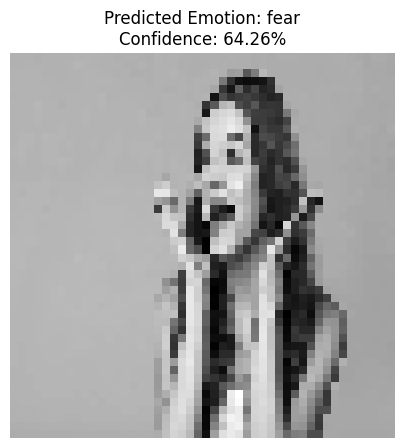

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(img, cmap='gray')

plt.title(
    f"Predicted Emotion: {predicted_emotion}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
probabilities = prediction[0] * 100

for emotion, probability in zip(class_names, probabilities):
    print(f"{emotion}: {probability:.2f}%")

angry: 4.84%
disgust: 0.10%
fear: 15.22%
happy: 3.43%
neutral: 44.57%
sad: 15.61%
surprise: 16.23%


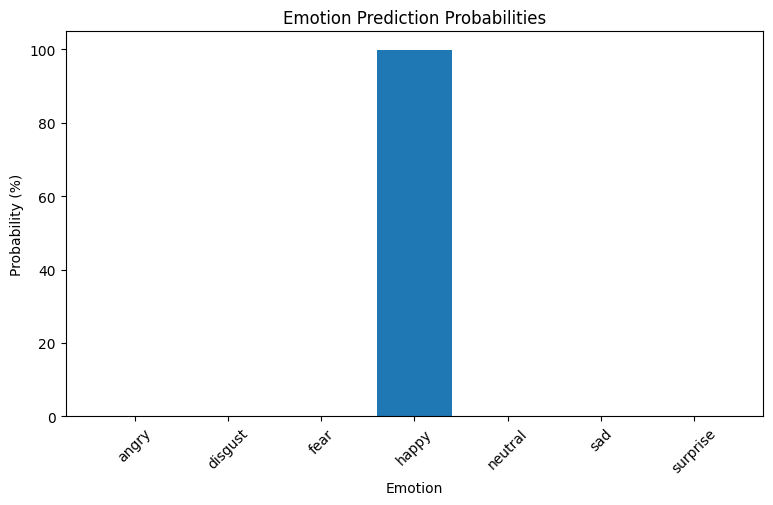

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(class_names, probabilities)

plt.xlabel("Emotion")
plt.ylabel("Probability (%)")
plt.title("Emotion Prediction Probabilities")

plt.xticks(rotation=45)
plt.show()